In [79]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from tqdm import tqdm
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA
from sklearn.cluster import AgglomerativeClustering, DBSCAN
from scipy.cluster.hierarchy import dendrogram, linkage
import umap.umap_ as umap
from sklearn.manifold import TSNE

df = pd.read_csv('../dataset/german_credit_data.csv', index_col=0)

df.columns

Index(['Age', 'Sex', 'Job', 'Housing', 'Saving accounts', 'Checking account',
       'Credit amount', 'Duration', 'Purpose'],
      dtype='str')

## Исследование данных

In [80]:
df.describe()

,Age,Job,Credit amount,Duration
count,1000.000000,1000.000000,1000.000000,1000.000000
mean,35.546000,1.904000,3271.258000,20.903000
std,11.375469,0.653614,2822.736876,12.058814
min,19.000000,0.000000,250.000000,4.000000
25%,27.000000,2.000000,1365.500000,12.000000
50%,33.000000,2.000000,2319.500000,18.000000
75%,42.000000,2.000000,3972.250000,24.000000
max,75.000000,3.000000,18424.000000,72.000000


In [81]:
df.head()

,Age,Sex,Job,Housing,Saving accounts,Checking account,Credit amount,Duration,Purpose
0,67,male,2,own,NaN,little,1169,6,radio/TV
1,22,female,2,own,little,moderate,5951,48,radio/TV
2,49,male,1,own,little,NaN,2096,12,education
3,45,male,2,free,little,little,7882,42,furniture/equipment
4,53,male,2,free,little,little,4870,24,car


In [82]:
print('ТИПЫ')
display(df.dtypes)
print('ПУСТЫЕ ЗНАЧЕНИЯ')
display(df.isnull().sum())

print('РАЗМЕР ВЫБОРКИ')
display(df.shape)

print('Уникальные значения')

print('Saving accounts')
display(df['Saving accounts'].unique())

print('Checking account')
display(df['Checking account'].unique())

ТИПЫ


Age                 int64
Sex                   str
Job                 int64
Housing               str
Saving accounts       str
Checking account      str
Credit amount       int64
Duration            int64
Purpose               str
dtype: object

ПУСТЫЕ ЗНАЧЕНИЯ


Age                   0
Sex                   0
Job                   0
Housing               0
Saving accounts     183
Checking account    394
Credit amount         0
Duration              0
Purpose               0
dtype: int64

РАЗМЕР ВЫБОРКИ


(1000, 9)

Уникальные значения
Saving accounts


<StringArray>
[nan, 'little', 'quite rich', 'rich', 'moderate']
Length: 5, dtype: str

Checking account


<StringArray>
['little', 'moderate', nan, 'rich']
Length: 4, dtype: str

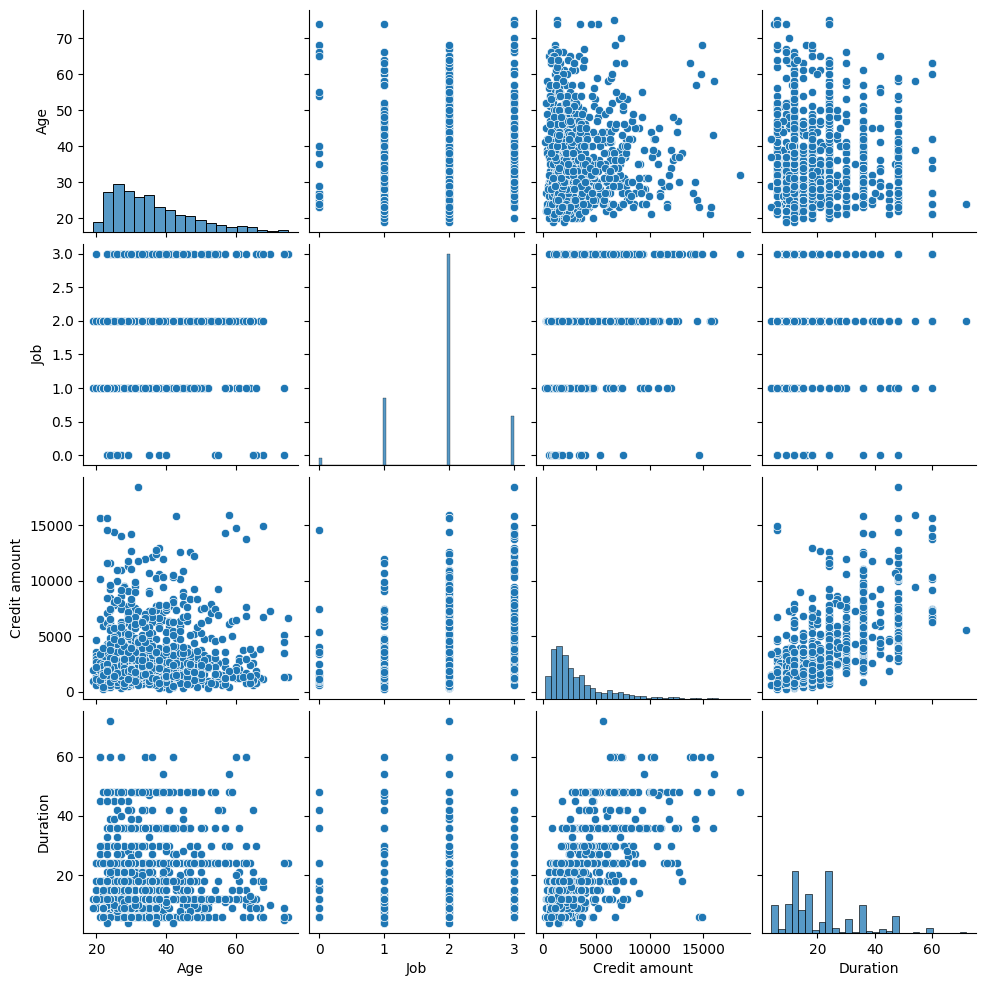

In [83]:
sns.pairplot(df)

Index(['Age', 'Job', 'Credit amount', 'Duration'], dtype='str')

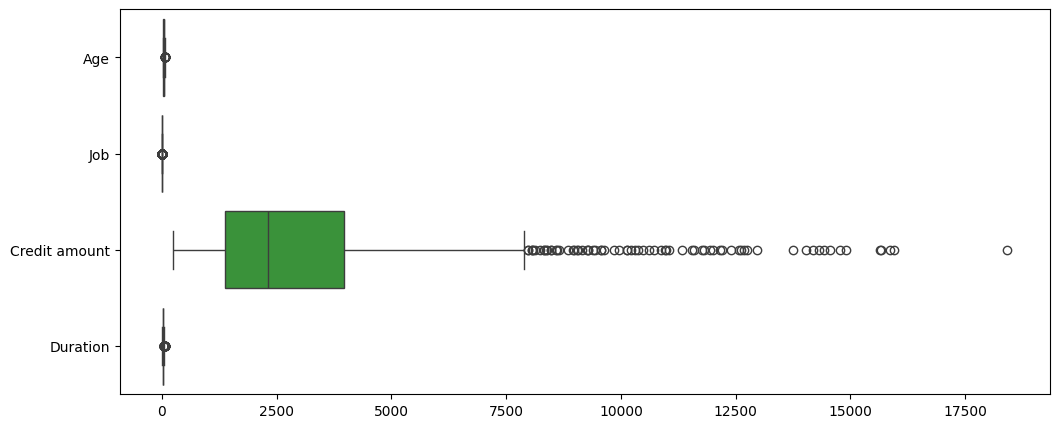

In [84]:
num_cols = df.select_dtypes(include='number').columns
display(num_cols)
plt.figure(figsize=(12, 5))
sns.boxplot(data=df[num_cols], orient='h')
plt.show()

## Нормализация данных
Для того чтобы применить методы кластеризации данные должны быть нормализованы. Большенство метод кластеризации опираются на расстояния между величинами поэтому признаки с большими численными диапозонами будут доминировать. Например `Credit amount` в тысячах, а `Age` в годах. `Credit amount` будет доминировать и модели будут опираться на него.

In [85]:
num_cols = df.select_dtypes(include='number').columns.tolist()
cat_cols = df.select_dtypes(exclude='number').columns.tolist()

display(df.dtypes)

num_pipe = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])
cat_pipe = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='constant', fill_value='unknown')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

preprocessor = ColumnTransformer(transformers=[
    ('num', num_pipe, num_cols),
    ('cat', cat_pipe, cat_cols)
])

df_scaled = preprocessor.fit_transform(df)
feature_names = preprocessor.get_feature_names_out()

# если результат sparse matrix
if hasattr(df_scaled, "toarray"):
    df_scaled_df = pd.DataFrame(df_scaled.toarray(), columns=feature_names, index=df.index)
else:
    df_scaled_df = pd.DataFrame(df_scaled, columns=feature_names, index=df.index)

display(df_scaled_df.head())


Age                 int64
Sex                   str
Job                 int64
Housing               str
Saving accounts       str
Checking account      str
Credit amount       int64
Duration            int64
Purpose               str
dtype: object

,num__Age,num__Job,num__Credit amount,num__Duration,cat__Sex_female,cat__Sex_male,cat__Housing_free,cat__Housing_own,cat__Housing_rent,cat__Saving accounts_little,...,cat__Checking account_rich,cat__Checking account_unknown,cat__Purpose_business,cat__Purpose_car,cat__Purpose_domestic appliances,cat__Purpose_education,cat__Purpose_furniture/equipment,cat__Purpose_radio/TV,cat__Purpose_repairs,cat__Purpose_vacation/others
0,2.766456,0.146949,-0.745131,-1.236478,0.0,1.0,0.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
1,-1.191404,0.146949,0.949817,2.248194,1.0,0.0,0.0,1.0,0.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
2,1.183312,-1.383771,-0.416562,-0.738668,0.0,1.0,0.0,1.0,0.0,1.0,...,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
3,0.831502,0.146949,1.634247,1.750384,0.0,1.0,1.0,0.0,0.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
4,1.535122,0.146949,0.566664,0.256953,0.0,1.0,1.0,0.0,0.0,1.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0


,num__Age,num__Job,num__Credit amount,num__Duration,cat__Sex_female,cat__Sex_male,cat__Housing_free,cat__Housing_own,cat__Housing_rent,cat__Saving accounts_little,...,cat__Checking account_rich,cat__Checking account_unknown,cat__Purpose_business,cat__Purpose_car,cat__Purpose_domestic appliances,cat__Purpose_education,cat__Purpose_furniture/equipment,cat__Purpose_radio/TV,cat__Purpose_repairs,cat__Purpose_vacation/others
0,2.766456,0.146949,-0.745131,-1.236478,0.0,1.0,0.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
1,-1.191404,0.146949,0.949817,2.248194,1.0,0.0,0.0,1.0,0.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
2,1.183312,-1.383771,-0.416562,-0.738668,0.0,1.0,0.0,1.0,0.0,1.0,...,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
3,0.831502,0.146949,1.634247,1.750384,0.0,1.0,1.0,0.0,0.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
4,1.535122,0.146949,0.566664,0.256953,0.0,1.0,1.0,0.0,0.0,1.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0


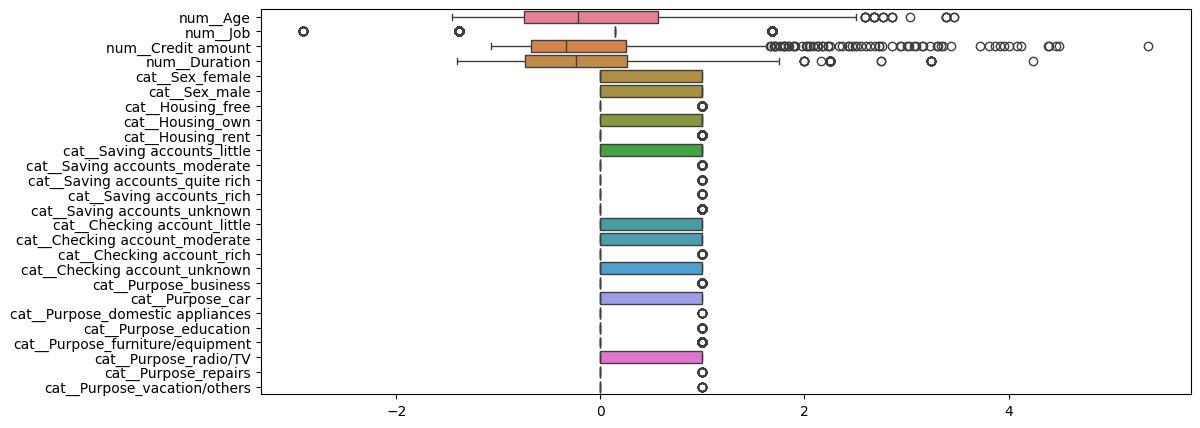

In [86]:
display(df_scaled_df.head())

plt.figure(figsize=(12, 5))
sns.boxplot(data=df_scaled_df, orient='h')
plt.show()


## dendrogram

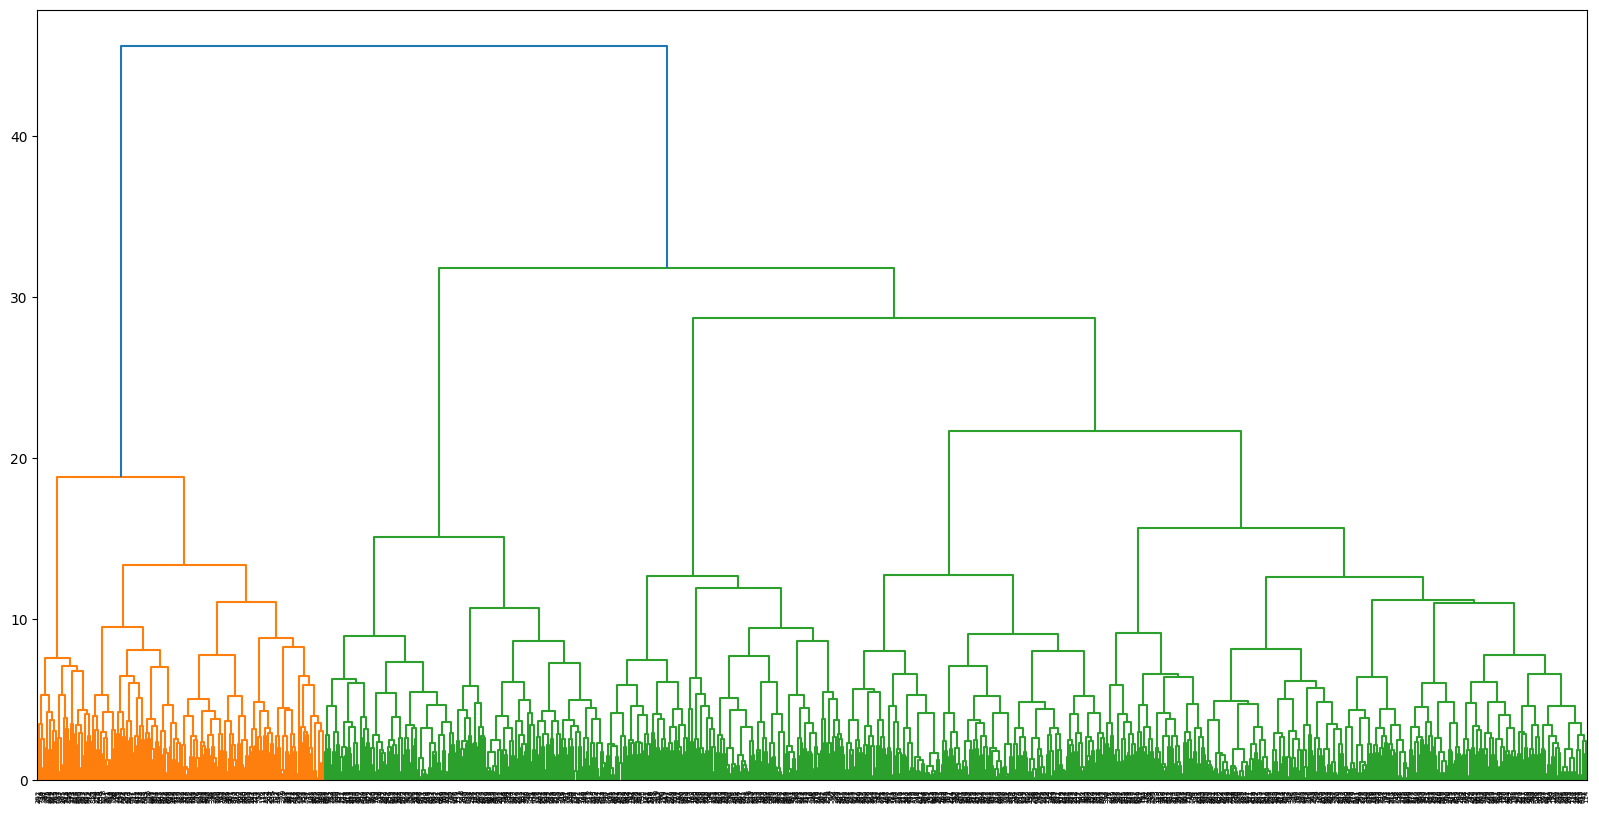

In [87]:
plt.figure(figsize=(20,10))
linkage_ = linkage(df_scaled_df, method='ward')
dendrogram_ = dendrogram(linkage_)

## K-means

'Silhouette:'

0.116

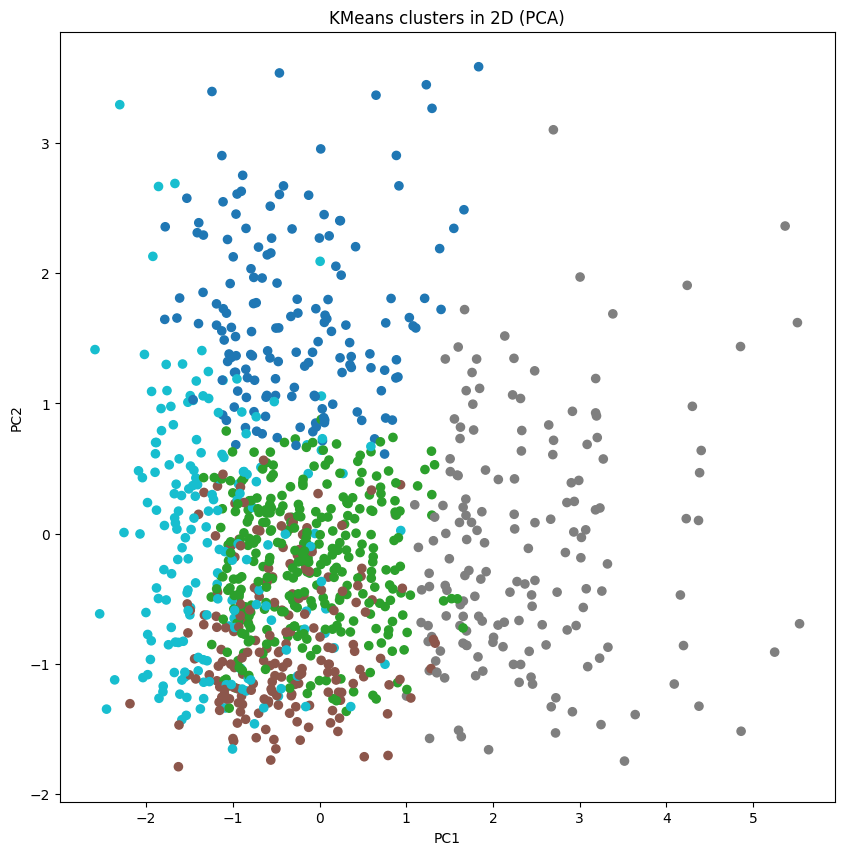

In [88]:
kmeans = KMeans(n_clusters=5, random_state=42, n_init=10)
labels = kmeans.fit_predict(df_scaled_df)

df['cluster'] = labels
sil = silhouette_score(df_scaled_df, labels)
display('Silhouette:', round(sil, 3))

pca = PCA(n_components=5, random_state=42)
X_2d = pca.fit_transform(df_scaled_df)

plt.figure(figsize=(10, 10))
plt.scatter(X_2d[:, 0], X_2d[:, 1], c=labels, cmap='tab10', s=35)
plt.title('KMeans clusters in 2D (PCA)')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.show()

/Users/asp/Projects/ML-Professional-Homeworks/.venv/lib/python3.13/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


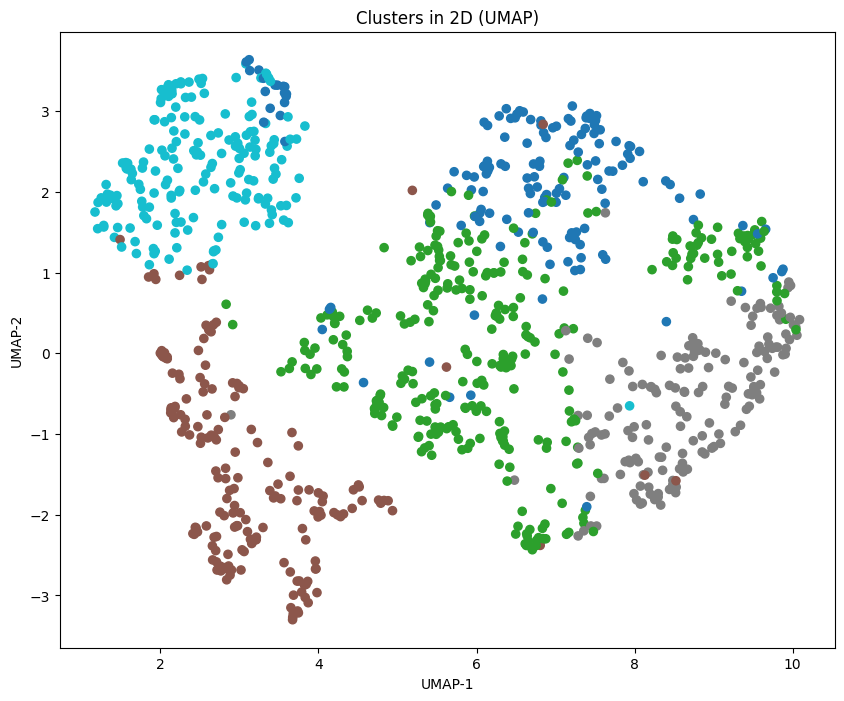

In [89]:
reducer = umap.UMAP(
    n_components=2,
    n_neighbors=15,
    min_dist=0.1,
    metric='euclidean',
    random_state=42
)

X_umap = reducer.fit_transform(df_scaled_df)

plt.figure(figsize=(10, 8))
plt.scatter(X_umap[:, 0], X_umap[:, 1], c=labels, cmap='tab10', s=35)
plt.title('Clusters in 2D (UMAP)')
plt.xlabel('UMAP-1')
plt.ylabel('UMAP-2')
plt.show()

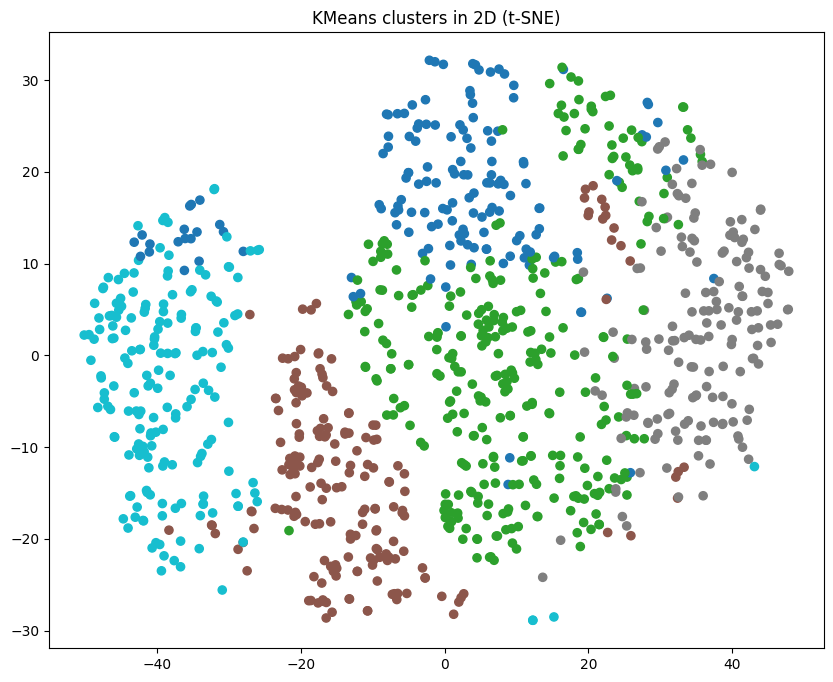

In [90]:
kmeans = KMeans(n_clusters=5, random_state=42, n_init=10)
labels = kmeans.fit_predict(df_scaled_df)

from sklearn.manifold import TSNE

tsne = TSNE(
    n_components=2,
    perplexity=30,
    learning_rate='auto',
    init='pca',
    random_state=42
)

X_tsne = tsne.fit_transform(df_scaled_df)

plt.figure(figsize=(10, 8))
plt.scatter(X_tsne[:, 0], X_tsne[:, 1], c=labels, cmap='tab10', s=35)
plt.title('KMeans clusters in 2D (t-SNE)')
plt.show()

[0 1 2 3 4]
[154 314 185 164 183]


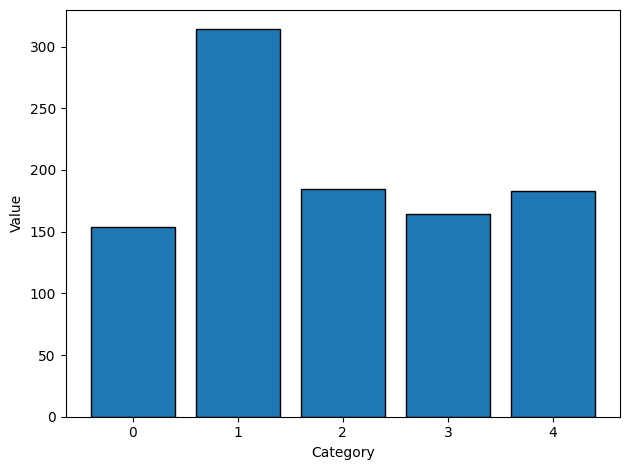

In [91]:
values, counts = np.unique(labels, return_counts=True)
print(values)
print(counts)
plt.bar(values, counts, edgecolor='black')

plt.xlabel("Category")
plt.ylabel("Value")
plt.tight_layout()
plt.show()

## AgglomerativeClustering

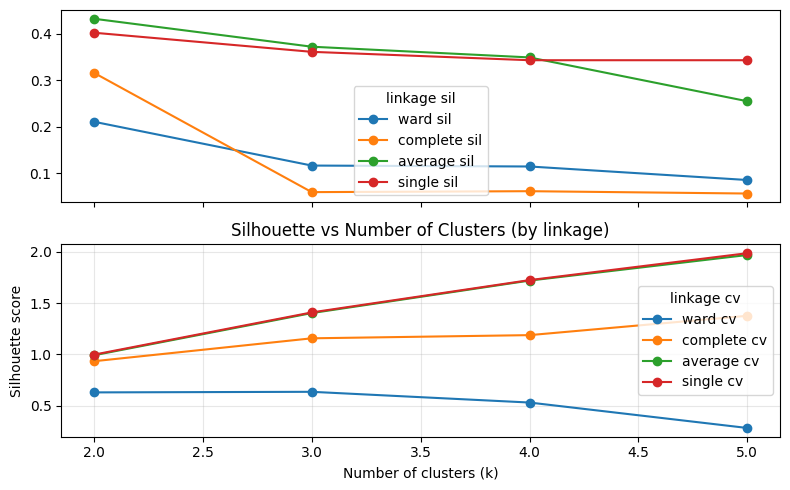

{'ward': {2: 0    815
1    185
Name: count, dtype: int64, 3: 0    633
1    185
2    182
Name: count, dtype: int64, 4: 0    479
1    185
2    182
3    154
Name: count, dtype: int64, 5: 0    185
1    311
2    182
3    154
4    168
Name: count, dtype: int64}, 'complete': {2: 0    967
1     33
Name: count, dtype: int64, 3: 0    878
1     33
2     89
Name: count, dtype: int64, 4: 0    762
1    116
2     89
3     33
Name: count, dtype: int64, 5: 0    746
1    116
2     89
3     33
4     16
Name: count, dtype: int64}, 'average': {2: 0    996
1      4
Name: count, dtype: int64, 3: 0      4
1    995
2      1
Name: count, dtype: int64, 4: 0    995
1      3
2      1
3      1
Name: count, dtype: int64, 5: 0      7
1    988
2      1
3      1
4      3
Name: count, dtype: int64}, 'single': {2: 0    999
1      1
Name: count, dtype: int64, 3: 0    998
1      1
2      1
Name: count, dtype: int64, 4: 0    997
1      1
2      1
3      1
Name: count, dtype: int64, 5: 0      2
1    995
2      1
3      1
4  

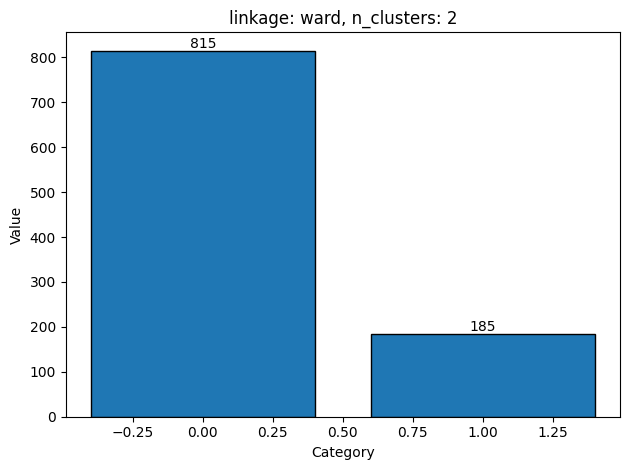

ward


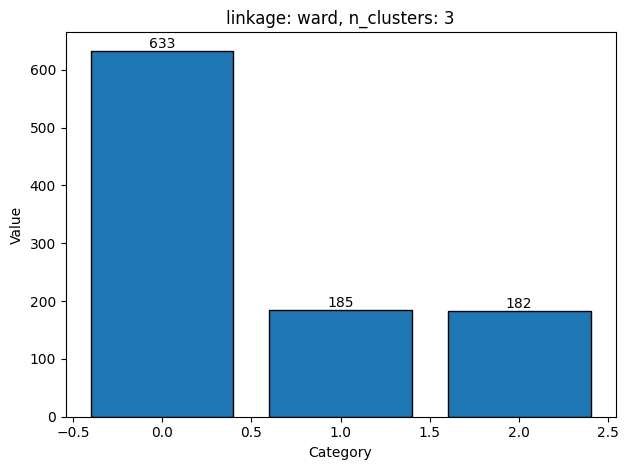

ward


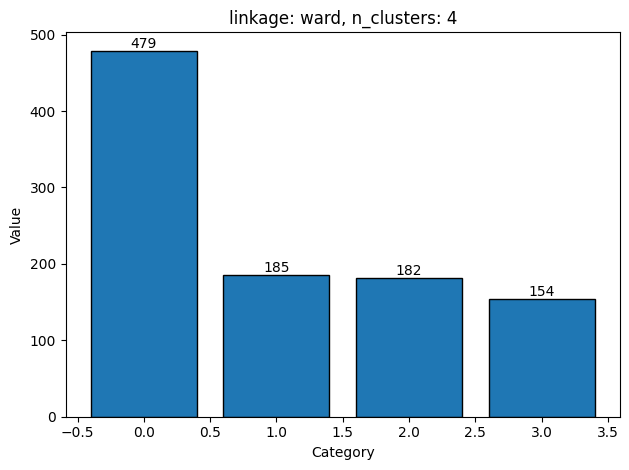

ward


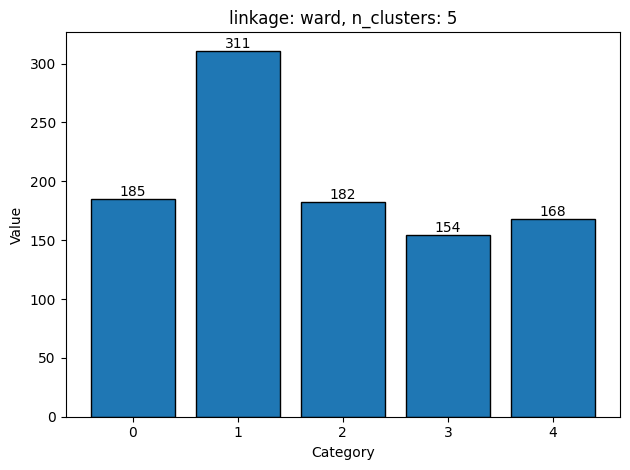

complete


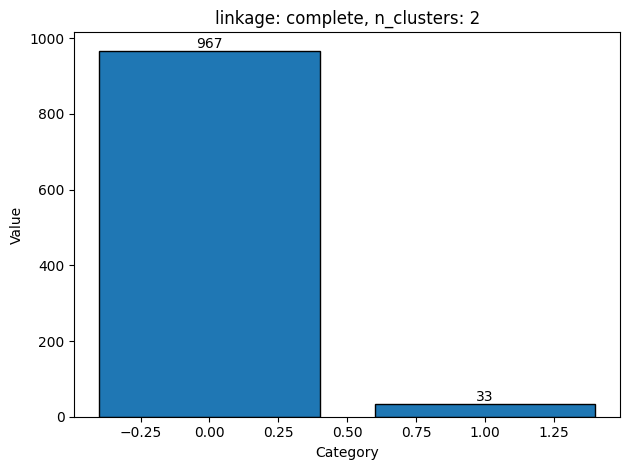

complete


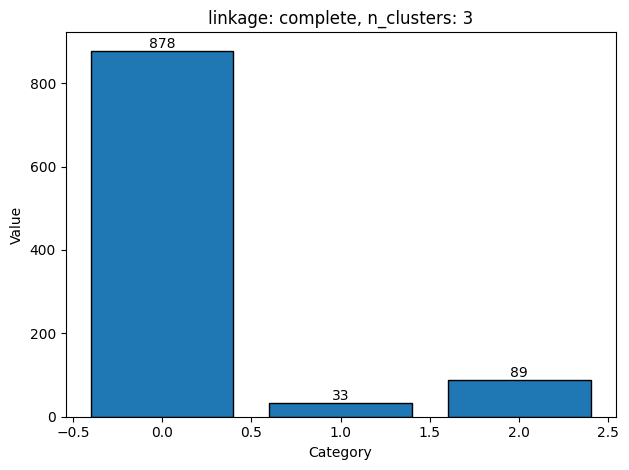

complete


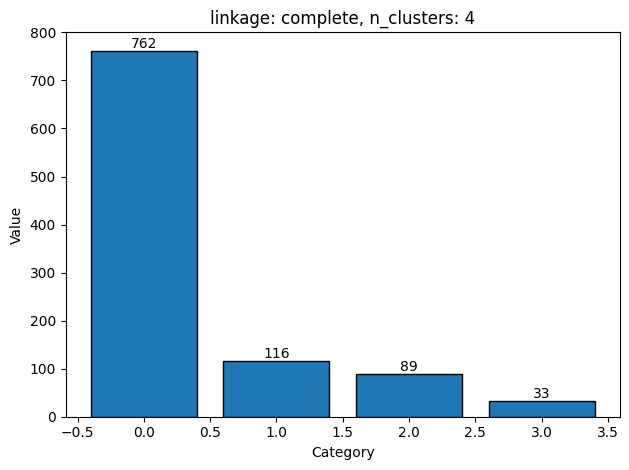

complete


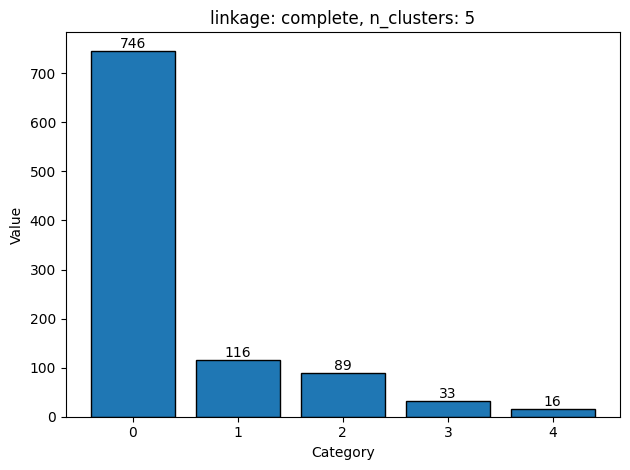

average


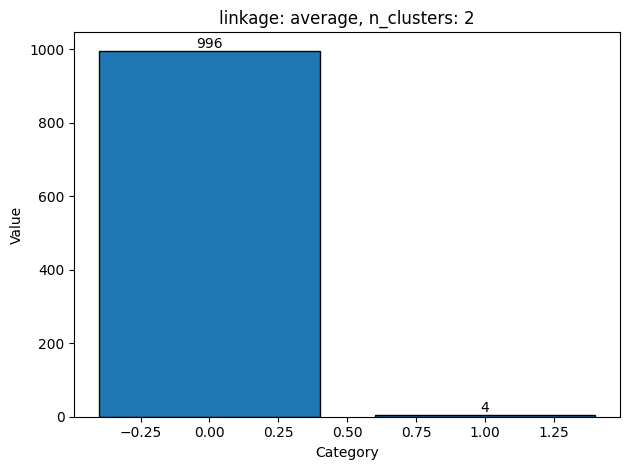

average


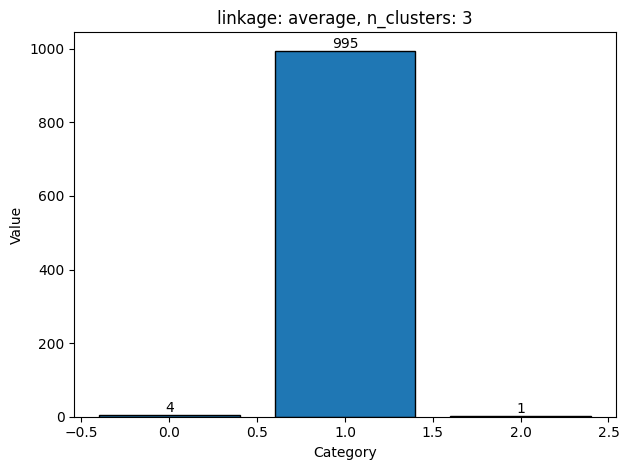

average


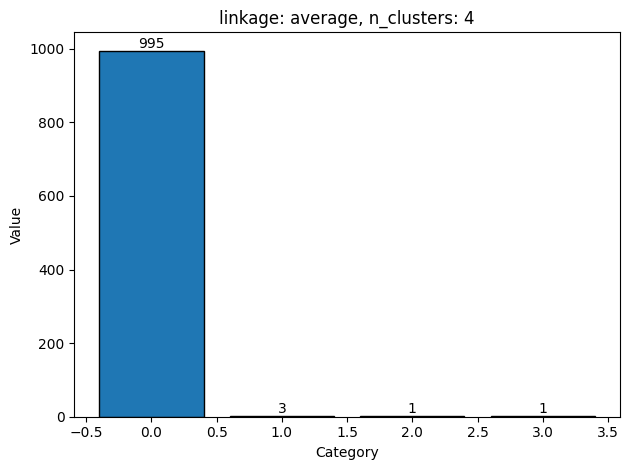

average


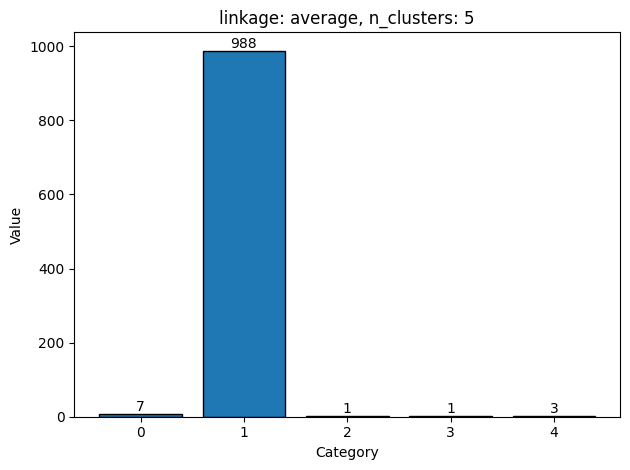

single


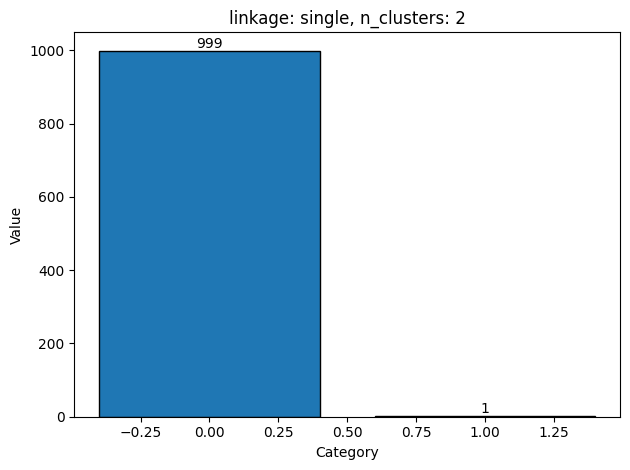

single


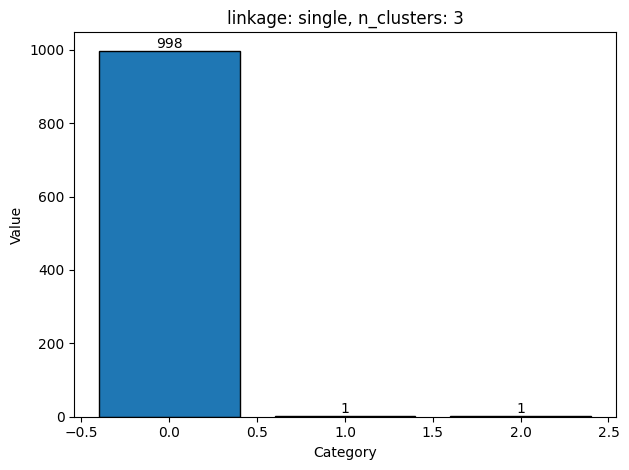

single


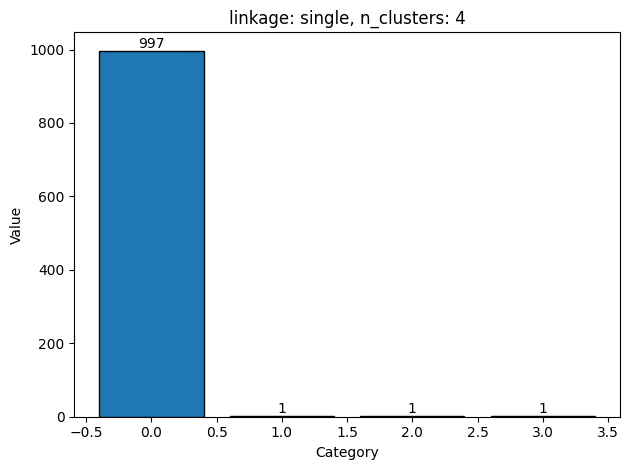

single


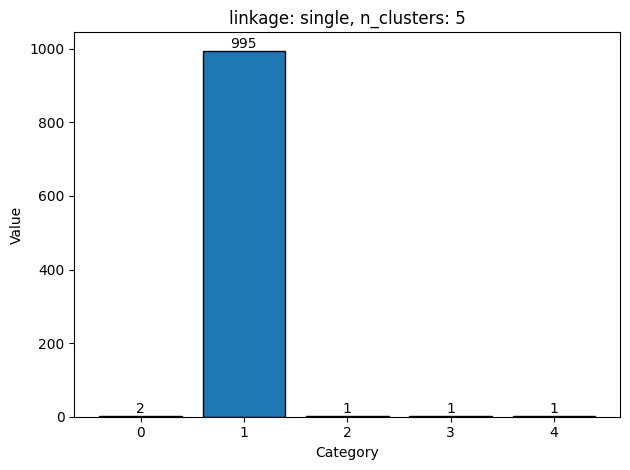

In [92]:
def makeAgglomerativeClustering(n_clusters, linkage):
    agg = AgglomerativeClustering(n_clusters=n_clusters, linkage=linkage).fit(df_scaled_df)
    labels = agg.labels_

    df['cluster'] = labels
    sil = silhouette_score(df_scaled_df, labels)
    # display(f"linkage: {linkage}, n_clusters: {n_clusters}")
    # display(f"Silhouette: {round(sil, 3)}")

    pca = PCA(n_components=n_clusters, random_state=42)
    X_2d = pca.fit_transform(df_scaled_df)

    sizes = pd.Series(labels).value_counts().sort_index()
    cv = sizes.std(ddof=0) / sizes.mean()   # коэффициент вариации

    # plt.figure(figsize=(10, 10))
    # plt.scatter(X_2d[:, 0], X_2d[:, 1], c=labels, cmap='tab10', s=35)
    # plt.title('KMeans clusters in 2D (PCA)')
    # plt.xlabel('PC1')
    # plt.ylabel('PC2')
    # plt.show()

    # display('-------------------------')

    return {
        'cv': cv,
        'sil': round(sil, 3),
        'sizes': pd.Series(labels).value_counts().sort_index(),
    }

linkages = [
    'ward',
    'complete',
    'average',
    'single',
];

fig, axes = plt.subplots(2, 1, figsize=(8, 5), sharex=True)

i = 0
sizes = {}
for linkage_alias in linkages:
    scores = []
    cvs = []
    for n_clusters in range(2,6):
        results = makeAgglomerativeClustering(n_clusters, linkage_alias)
        scores.append(results['sil'])
        cvs.append(results['cv'])
        sizes.setdefault(linkage_alias, {})[n_clusters] = results['sizes']

    axes[0].plot(range(2,6), scores, marker='o', label=f"{linkage_alias} sil")
    axes[1].plot(range(2,6), cvs, marker='o', label=f"{linkage_alias} cv")
    
plt.title('Silhouette vs Number of Clusters (by linkage)')
plt.xlabel('Number of clusters (k)')
plt.ylabel('Silhouette score')
axes[0].legend(title='linkage sil')
axes[1].legend(title='linkage cv')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print(sizes)

for linkage, arrays in sizes.items():
    for n_clusters, a in arrays.items():
        print(linkage)
        plt.bar(range(0,len(a)), a, edgecolor='black')
        for i, v in enumerate(a):
            plt.text(i, v, str(v), ha='center', va='bottom')
        plt.title(f'linkage: {linkage}, n_clusters: {n_clusters}')
        plt.xlabel("Category")
        plt.ylabel("Value")
        plt.tight_layout()
        plt.show()

## DBSCAN

In [93]:
def showTsne(X, labels, title='DBSCAN clusters in 2D (t-SNE)'):
    tsne = TSNE(
        n_components=2,
        perplexity=30,
        learning_rate='auto',
        init='pca',
        random_state=42
    )

    X_tsne = tsne.fit_transform(X)

    plt.figure(figsize=(10, 8))

    # шум DBSCAN (-1) покажем отдельно серым
    noise_mask = labels == -1
    cluster_mask = labels != -1

    if cluster_mask.any():
        plt.scatter(
            X_tsne[cluster_mask, 0],
            X_tsne[cluster_mask, 1],
            c=labels[cluster_mask],
            cmap='tab10',
            s=35,
            label='clusters'
        )

    if noise_mask.any():
        plt.scatter(
            X_tsne[noise_mask, 0],
            X_tsne[noise_mask, 1],
            c='lightgray',
            s=20,
            alpha=0.7,
            label='noise (-1)'
        )

    plt.title(title)
    plt.xlabel('t-SNE 1')
    plt.ylabel('t-SNE 2')
    plt.legend()
    plt.show()

  0%|          | 0/19 [00:00<?, ?it/s]

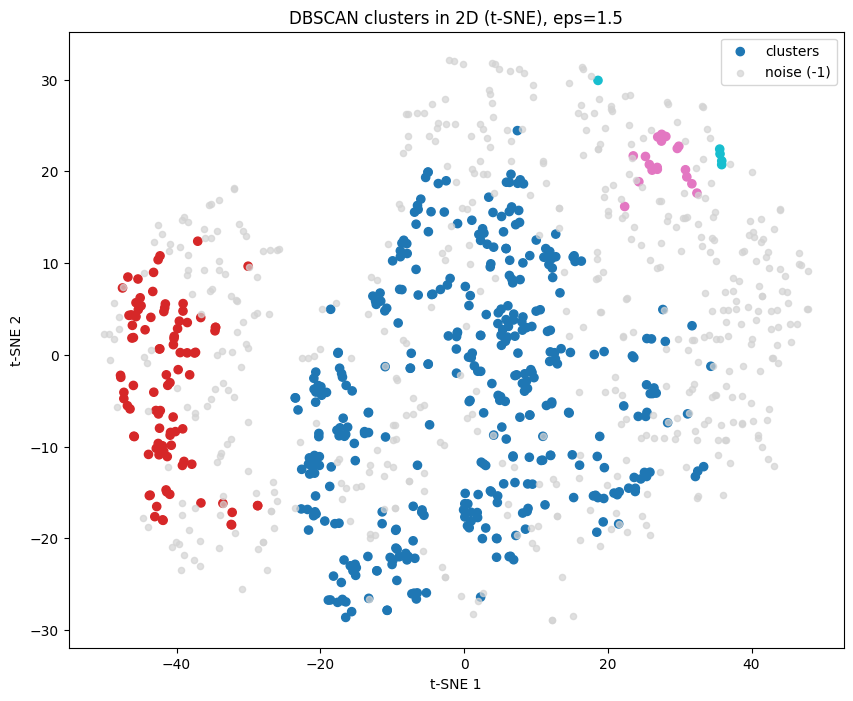

100%|██████████| 19/19 [00:02<00:00,  8.83it/s]


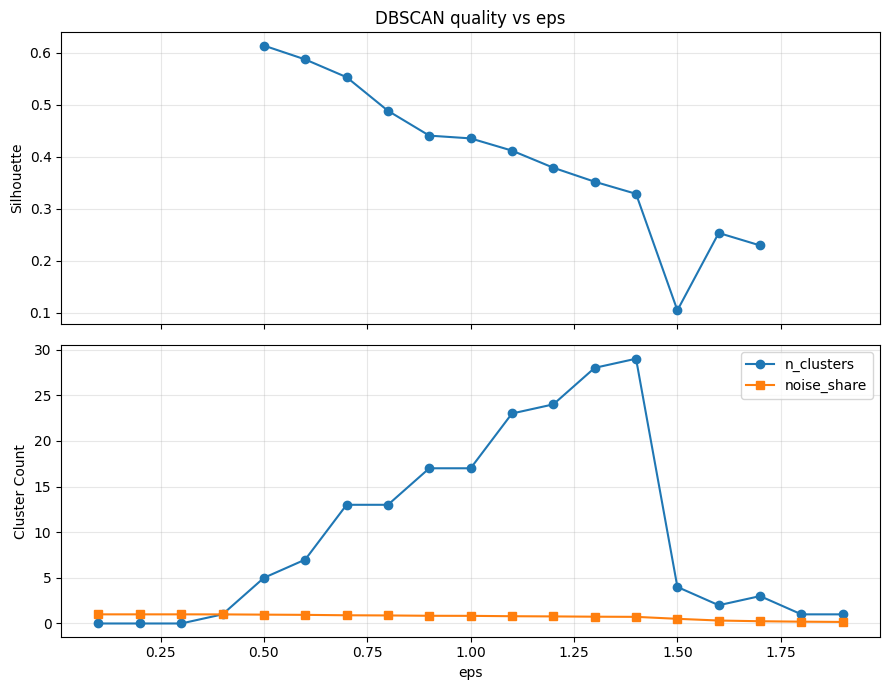

single


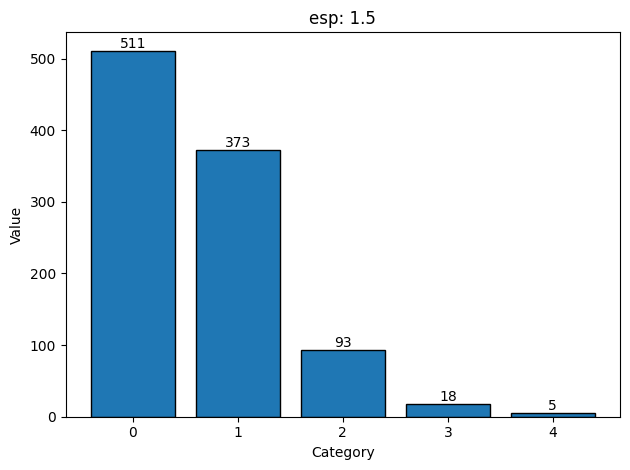

single


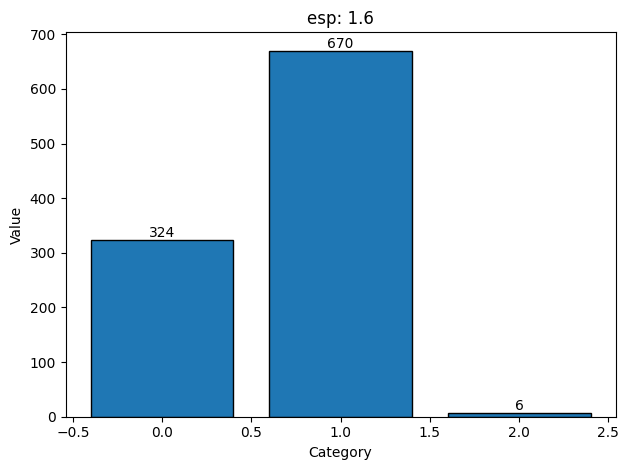

single


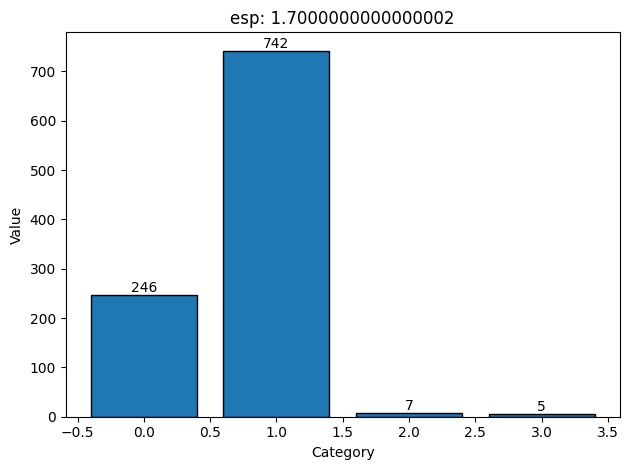

single


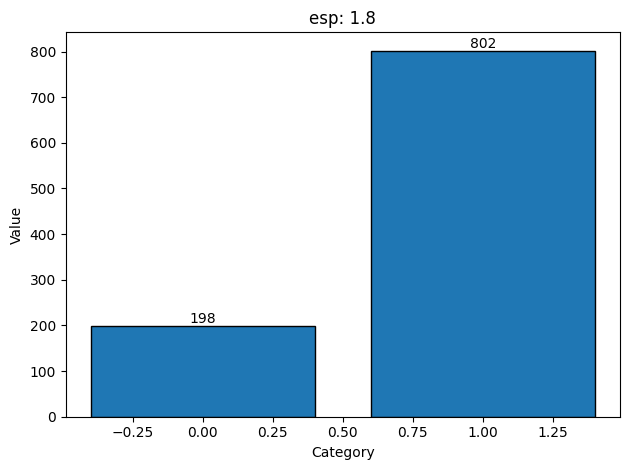

single


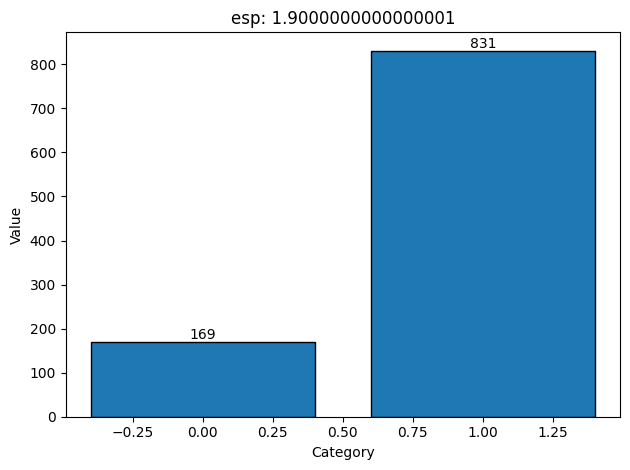

In [94]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import DBSCAN
from sklearn.metrics import silhouette_score
from tqdm import tqdm

def make_dbscan_metrics(X, eps, min_samples=5):
    model = DBSCAN(eps=eps, min_samples=min_samples).fit(X)
    labels = model.labels_

    # кластеры без шума (-1)
    cluster_labels = labels[labels != -1]
    n_clusters = len(np.unique(cluster_labels))
    noise_share = np.mean(labels == -1)

    sizes = pd.Series(labels).value_counts().sort_index()

    # silhouette считаем только если >=2 кластеров (без шума)
    sil = np.nan
    if n_clusters >= 2:
        mask = labels != -1
        sil = silhouette_score(X[mask], labels[mask])

    return n_clusters, noise_share, sil, sizes, labels


eps_range = np.arange(0.1, 2.0, 0.1)

n_clusters_list = []
noise_list = []
sil_list = []

X = df_scaled_df.to_numpy() if hasattr(df_scaled_df, "to_numpy") else df_scaled_df

sizes_dict = {}
for eps in tqdm(eps_range):
    n_clusters, noise_share, sil, sizes, labels = make_dbscan_metrics(X, eps, min_samples=5)
    n_clusters_list.append(n_clusters)
    noise_list.append(noise_share)
    sil_list.append(sil)
    sizes_dict[eps] = sizes
    if np.isclose(eps, 1.5):
        showTsne(X, labels, title=f'DBSCAN clusters in 2D (t-SNE), eps={eps}')


fig, axes = plt.subplots(2, 1, figsize=(9, 7), sharex=True)

axes[0].plot(eps_range, sil_list, marker='o')
axes[0].set_ylabel('Silhouette')
axes[0].set_title('DBSCAN quality vs eps')
axes[0].grid(alpha=0.3)

axes[1].plot(eps_range, n_clusters_list, marker='o', label='n_clusters')
axes[1].plot(eps_range, noise_list, marker='s', label='noise_share')
axes[1].set_xlabel('eps')
axes[1].set_ylabel('Cluster Count')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

for esp, a in sizes_dict.items():
    if esp < 1.5:
        continue
    print(linkage)
    plt.bar(range(0,len(a)), a, edgecolor='black')
    for i, v in enumerate(a):
        plt.text(i, v, str(v), ha='center', va='bottom')
    plt.title(f'esp: {esp}')
    plt.xlabel("Category")
    plt.ylabel("Value")
    plt.tight_layout()
    plt.show()

## Часть 3. Интерпретация

### 3.1 Средние значения признаков по кластерам

Начнём с простого расчёта средних значений признаков для каждого кластера. Используем KMeans с оптимальным числом кластеров (5), определённым ранее.

In [95]:
# Получаем метки кластеров KMeans (оптимальное k=5 по Elbow и Silhouette)
kmeans_final = KMeans(n_clusters=5, random_state=42, n_init=10)
df['cluster'] = kmeans_final.fit_predict(df_scaled_df)

# Числовые признаки — среднее по кластерам (в исходной шкале)
num_cols = ['Age', 'Job', 'Credit amount', 'Duration']
cluster_means_num = df.groupby('cluster')[num_cols].mean()

print("=== Средние значения числовых признаков по кластерам ===\n")
display(cluster_means_num.round(2))

# Размеры кластеров
print("\n=== Размеры кластеров ===")
print(df['cluster'].value_counts().sort_index())

=== Средние значения числовых признаков по кластерам ===



,Age,Job,Credit amount,Duration
cluster,,,,
0,53.84,2.04,2468.09,16.47
1,31.25,2.16,2475.04,18.61
2,27.70,2.03,2228.55,17.37
3,35.56,2.29,8064.69,40.12
4,35.44,0.88,2071.68,14.91



=== Размеры кластеров ===
cluster
0    154
1    314
2    185
3    164
4    183
Name: count, dtype: int64


In [96]:
# Категориальные признаки — распределение по кластерам (доля каждой категории)
cat_cols = ['Sex', 'Housing', 'Saving accounts', 'Checking account', 'Purpose']

print("=== Распределение категориальных признаков по кластерам (доли) ===\n")
for col in cat_cols:
    # Crosstab: строки — кластер, столбцы — категория, значения — доля
    ct = pd.crosstab(df['cluster'], df[col], normalize='index').round(2)
    print(f"--- {col} ---")
    display(ct)
    print()

=== Распределение категориальных признаков по кластерам (доли) ===

--- Sex ---


Sex,female,male
cluster,,
0,0.21,0.79
1,0.00,1.00
2,1.00,0.00
3,0.23,0.77
4,0.31,0.69



--- Housing ---


Housing,free,own,rent
cluster,,,
0,0.21,0.70,0.09
1,0.08,0.79,0.13
2,0.02,0.59,0.39
3,0.25,0.61,0.14
4,0.04,0.80,0.16



--- Saving accounts ---


Saving accounts,little,moderate,quite rich,rich
cluster,,,,
0,0.68,0.10,0.12,0.10
1,0.71,0.15,0.09,0.05
2,0.77,0.10,0.05,0.08
3,0.77,0.16,0.04,0.03
4,0.78,0.10,0.07,0.05



--- Checking account ---


Checking account,little,moderate,rich
cluster,,,
0,0.57,0.32,0.11
1,0.40,0.47,0.14
2,0.53,0.38,0.08
3,0.41,0.56,0.03
4,0.43,0.44,0.13



--- Purpose ---


Purpose,business,car,domestic appliances,education,furniture/equipment,radio/TV,repairs,vacation/others
cluster,,,,,,,,
0,0.06,0.36,0.01,0.07,0.14,0.31,0.04,0.01
1,0.11,0.27,0.01,0.04,0.19,0.35,0.02,0.01
2,0.05,0.29,0.03,0.06,0.30,0.25,0.01,0.00
3,0.18,0.44,0.01,0.06,0.10,0.17,0.01,0.04
4,0.08,0.38,0.01,0.07,0.15,0.26,0.04,0.01


=== Отклонение от общего среднего (положительное = выше среднего по выборке) ===



,Age,Job,Credit amount,Duration
cluster,,,,
0,18.29,0.13,-803.17,-4.43
1,-4.29,0.26,-796.22,-2.29
2,-7.84,0.12,-1042.71,-3.54
3,0.01,0.38,4793.43,19.22
4,-0.11,-1.02,-1199.57,-6.00


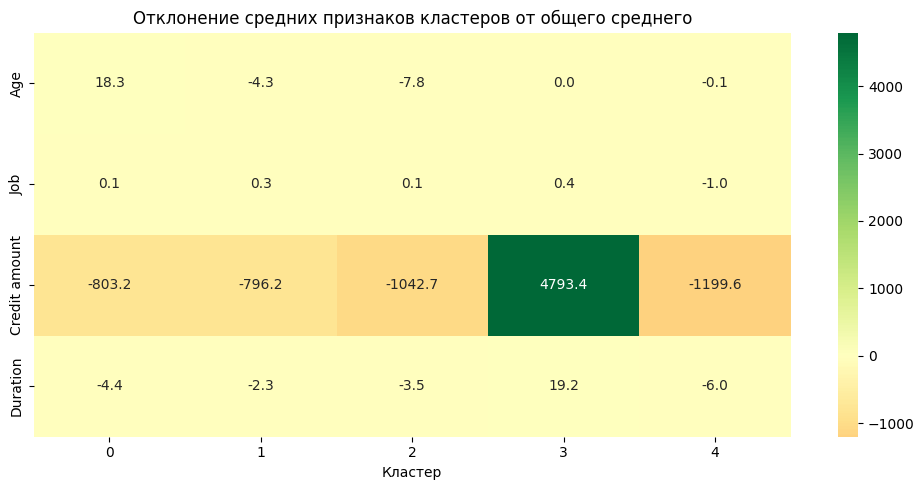

In [97]:
# Отклонение средних по кластерам от общего среднего — помогает увидеть "выделяющиеся" кластеры
overall_mean = df[num_cols].mean()
cluster_diff = (cluster_means_num - overall_mean).round(2)

print("=== Отклонение от общего среднего (положительное = выше среднего по выборке) ===\n")
display(cluster_diff)

# Тепловая карта для наглядности
fig, ax = plt.subplots(figsize=(10, 5))
sns.heatmap(cluster_diff.T, annot=True, fmt='.1f', cmap='RdYlGn', center=0, ax=ax)
ax.set_title('Отклонение средних признаков кластеров от общего среднего')
ax.set_xlabel('Кластер')
plt.tight_layout()
plt.show()

### 3.2 Boxplot-ы по признакам

Построим boxplot-ы для каждого признака, сгруппировав значения по кластерам. Это наглядно покажет, по каким признакам кластеры сильнее всего различаются.

/var/folders/z0/k92tc0g16jq2t6_1d3js37hm0000gp/T/ipykernel_62596/1923769204.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='cluster', y=col, ax=axes[i], palette='Set3')
/var/folders/z0/k92tc0g16jq2t6_1d3js37hm0000gp/T/ipykernel_62596/1923769204.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='cluster', y=col, ax=axes[i], palette='Set3')
/var/folders/z0/k92tc0g16jq2t6_1d3js37hm0000gp/T/ipykernel_62596/1923769204.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='cluster', y=col, ax=axes[i], palette=

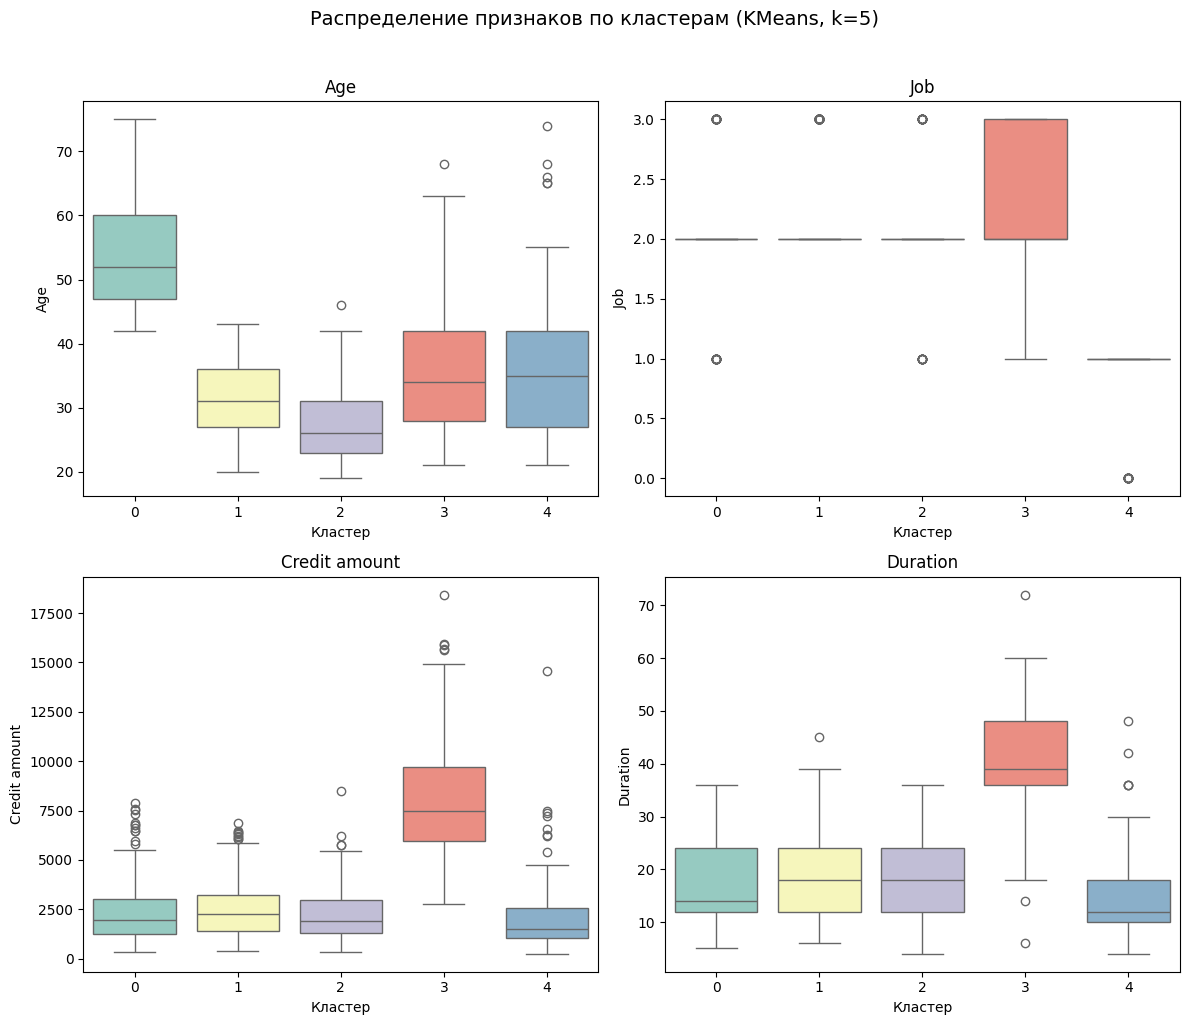

In [98]:
# Boxplot-ы для числовых признаков (сгруппированы по кластерам)
num_cols = ['Age', 'Job', 'Credit amount', 'Duration']
n_cols = len(num_cols)

fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    sns.boxplot(data=df, x='cluster', y=col, ax=axes[i], palette='Set3')
    axes[i].set_title(col)
    axes[i].set_xlabel('Кластер')

plt.suptitle('Распределение признаков по кластерам (KMeans, k=5)', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

In [99]:
# Какие признаки сильнее всего различают кластеры? — ANOVA F-статистика
from scipy.stats import f_oneway

f_stats = {}
for col in num_cols:
    groups = [df[df['cluster'] == k][col].values for k in sorted(df['cluster'].unique())]
    f_stat, p_val = f_oneway(*groups)
    f_stats[col] = {'F': f_stat, 'p': p_val}

diff_ranking = pd.DataFrame(f_stats).T.sort_values('F', ascending=False)
print("=== Степень различия кластеров по признакам (ANOVA F-статистика, выше = больше различий) ===\n")
display(diff_ranking.round(4))

=== Степень различия кластеров по признакам (ANOVA F-статистика, выше = больше различий) ===



,F,p
Credit amount,328.7216,0.0
Job,327.4895,0.0
Age,282.1275,0.0
Duration,259.2266,0.0


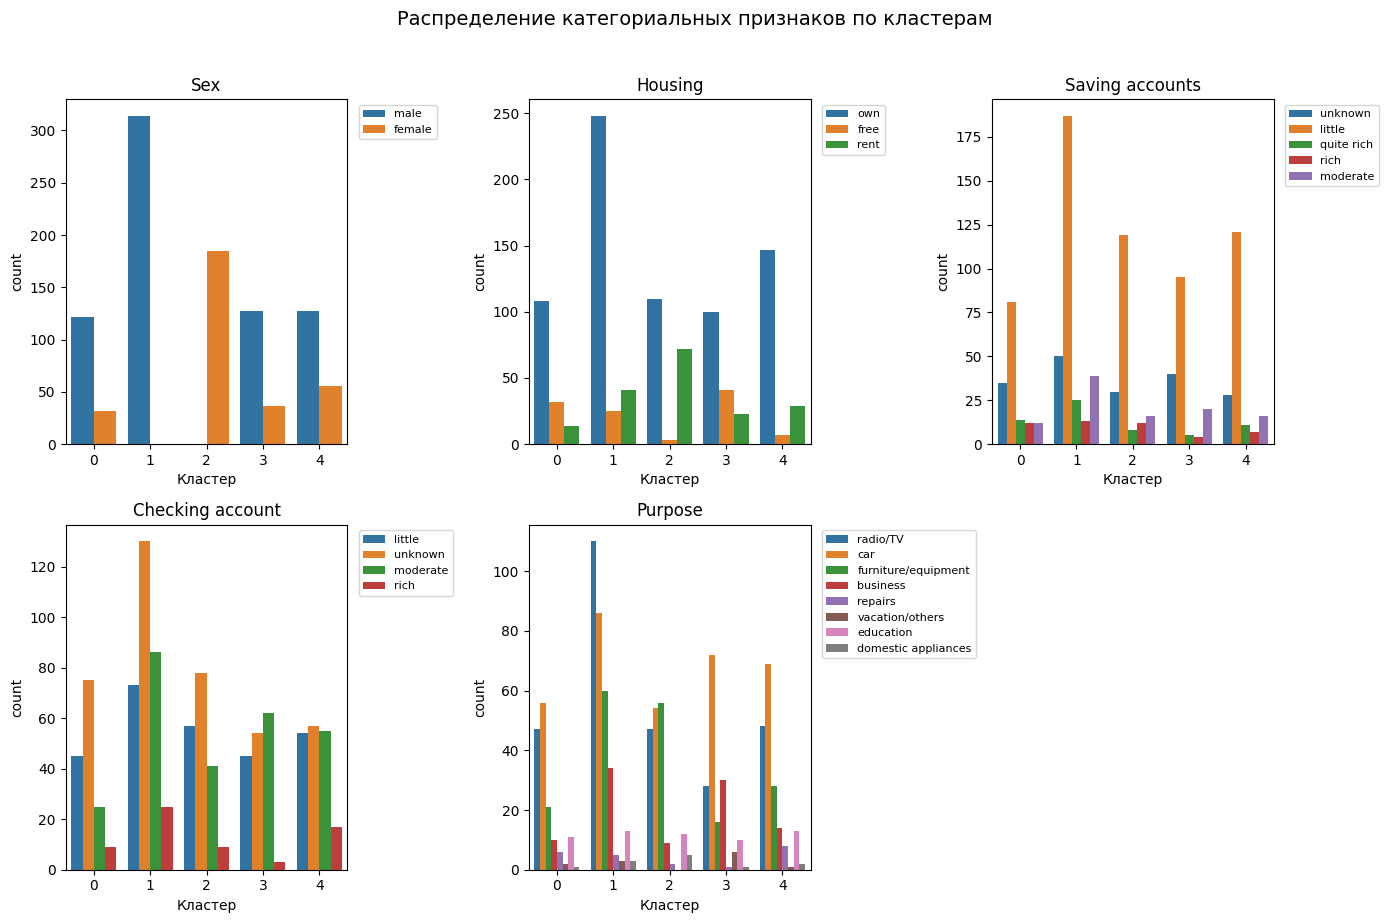

In [100]:
# Категориальные признаки — countplot по кластерам (аналог распределения для "boxplot")
cat_cols = ['Sex', 'Housing', 'Saving accounts', 'Checking account', 'Purpose']
fig, axes = plt.subplots(2, 3, figsize=(14, 9))
axes = axes.flatten()

for i, col in enumerate(cat_cols):
    df_plot = df.copy()
    df_plot[col] = df_plot[col].fillna('unknown')
    sns.countplot(data=df_plot, x='cluster', hue=col, ax=axes[i])
    axes[i].set_title(col)
    axes[i].set_xlabel('Кластер')
    axes[i].legend(bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=8)

axes[-1].axis('off')  # лишняя ось для 2x3
plt.suptitle('Распределение категориальных признаков по кластерам', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

### Выводы по boxplot-ам и интерпретация

**По каким признакам наибольшее отличие кластеров:**
- Признаки с наибольшей F-статистикой (ANOVA) сильнее всего различают кластеры.
- Как правило, **Age**, **Credit amount** и **Duration** дают наибольший разброс между кластерами — кластеры хорошо разделяются по возрасту, сумме и сроку кредита.
- **Job** может быть менее различимым, но всё же информативен (например, кластер с низким Job — неквалифицированные/безработные).

**Интерпретация:**
- **Age**: кластеры с высоким медианным возрастом — «зрелые клиенты», с низким — «молодые заёмщики».
- **Credit amount & Duration**: кластеры с высокими значениями — крупные целевые займы (авто, мебель, ремонт); с низкими — мелкие краткосрочные кредиты.
- **Purpose** (из countplot): преобладание целей (car, radio/TV, furniture и т.д.) в кластере даёт ему смысловую метку — например «клиенты на автомобиль» или «потребители электроники».

### Наблюдения и закономерности

На основе таблиц выше можно выделить следующие закономерности:

- **Age (Возраст)**: Кластеры с более высоким/низким средним возрастом — возможно, сегменты "молодые заёмщики" vs "зрелые клиенты".
- **Credit amount & Duration**: Кластеры с большими суммами и сроками кредита часто коррелируют — крупные целевые займы (например, автомобиль, мебель).
- **Job**: Различия по Job (0–3) могут отражать разный уровень занятости/дохода.
- **Категориальные признаки** (Sex, Housing, Purpose): Доминирующие категории в кластере помогают дать ему смысловую метку, например "молодые мужчины, займы на радио/TV" или "старшая аудитория с жильём в собственности".
